# Loss Functions

How should we score a model's mistakes? We will calculate regression and classification losses by hand with tensors, compare them with PyTorch's implementations, and inspect how confidence, outliers, and averaging affect the results.

A loss assigns a penalty to a prediction and its target. These are fixed, invented examples; no model is trained and no predictive performance on unseen data is claimed. All calculations run on CPU without downloads or credentials. Run the cells in order from a fresh kernel using the [README setup](README.md). PyTorch and Matplotlib are required. The [notes](06_Loss_Functions_Notes.ipynb) provide optional background.

## Start with the problem this lesson solves

An ANN can output a prediction before it has learned anything. To improve it, we need a numerical rule for judging a prediction against its target. A **loss function** turns a mistake into a scalar that can guide learning.

The rule matters: being two degrees wrong, missing an urgent positive case, and assigning very low probability to the true class are different kinds of mistakes. A loss makes the chosen preference explicit; it does not by itself update the network.

## Calculate a loss and see the learning direction it creates

**Numeric prediction.** In this small illustrative temperature example, targets are $[20,22]$ and predictions are $[18,25]$. Subtract target from prediction: errors are $[-2,3]$. Their ordinary average is $0.5$, which hides the two substantial misses by cancellation.

Absolute values give $[2,3]$, so mean absolute error is $(2+3)/2=2.5$ degrees. Squares give $[4,9]$, so mean squared error is $(4+9)/2=6.5$ squared degrees. The three-degree miss contributes nine rather than three, making large errors count more strongly.

For MSE on $N$ predictions, the derivative with respect to prediction $i$ is $2(\hat y_i-y_i)/N$. With $N=2$, the gradients are $[-2,3]$. Reducing loss calls for increasing the first prediction and decreasing the second. If predictions themselves were independently adjustable parameters, an SGD rate of $0.1$ would change them to $[18.2,24.7]$. New errors are $[-1.8,2.7]$ and new MSE is $(3.24+7.29)/2=5.265$. In an ANN, predictions are not independent parameters: the chain rule carries these signals back into shared weights.

**Binary classification.** If the true label is one and the model assigns it probability $p=0.8$, binary cross-entropy is $-\ln(0.8)\approx0.223144$. Assigning $p=0.2$ gives $-\ln(0.2)\approx1.609438$. The natural logarithm makes confident wrong answers expensive. For a zero target, use $-\ln(1-p)$ instead.

**Three competing classes.** Let logits be $[2,1,0]$ and the true class be the first. Exponentiate: $[e^2,e^1,e^0]\approx[7.389056,2.718282,1]$. Their sum is $11.107338$. Divide each by the sum to get probabilities approximately $[0.665241,0.244728,0.090031]$. Loss is $-\ln(0.665241)\approx0.407606$.

For softmax cross-entropy on this one example, logit gradients equal probabilities minus the one-hot target: approximately $[-0.334759,0.244728,0.090031]$. An update therefore tends to raise the true class's logit and lower the others. The network learns which weights can produce those changes.

## Why loss is more informative than a right-or-wrong count

Accuracy only changes when a decision crosses a boundary. Cross-entropy can improve when probability on the true class rises from 0.6 to 0.8, even though both answers count as correct. This gives learning a more informative signal.

Choose the loss according to the prediction's meaning. MSE is natural for many numeric targets; binary and multiclass cross-entropy correspond to different label structures. Keep predictions and targets aligned, and check whether a reduction sums or averages. A small training loss is evidence of fitting training examples, not proof of good predictions on new ones.

## Connect the explanation to the code

`prediction - target` computes signed errors; `.abs()` and `.square()` choose how to penalize them; `.mean()` combines them. `BCEWithLogitsLoss` combines sigmoid and binary cross-entropy stably. `CrossEntropyLoss` handles softmax and negative log probability internally for multiclass logits. The miniature two-temperature calculation above is separate from the companion's existing temperature table.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import platform
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version(), "| PyTorch:", torch.__version__)
print("CPU | fixed predictions, no training")

Python: 3.9.6 | PyTorch: 2.2.2
CPU | fixed predictions, no training


## Start with temperature errors

Targets and predictions are columns: one value per greenhouse. MAE averages absolute errors, MSE averages squared errors, and RMSE takes the square root of MSE. `reduction="none"` exposes individual penalties before averaging. We check the library output against both the explicit calculation and the worked answer.

In [2]:
target = torch.tensor([[20.], [22.], [24.]])
prediction = torch.tensor([[19.], [24.], [21.]])
assert prediction.shape == target.shape
error = prediction - target
absolute = nn.L1Loss(reduction="none")(prediction, target)
squared = nn.MSELoss(reduction="none")(prediction, target)
torch.testing.assert_close(absolute, error.abs())
torch.testing.assert_close(squared, error.square())
torch.testing.assert_close(absolute.mean(), torch.tensor(2.))
torch.testing.assert_close(squared.mean(), torch.tensor(14. / 3.))
print("Signed errors:", error.flatten().tolist())
print("Absolute penalties:", absolute.flatten().tolist())
print("Squared penalties:", squared.flatten().tolist())
print(f"MAE: {absolute.mean():.3f} degrees")
print(f"MSE: {squared.mean():.3f} squared degrees")
print(f"RMSE: {squared.mean().sqrt():.3f} degrees")

Signed errors: [-1.0, 2.0, -3.0]
Absolute penalties: [1.0, 2.0, 3.0]
Squared penalties: [1.0, 4.0, 9.0]
MAE: 2.000 degrees
MSE: 4.667 squared degrees
RMSE: 2.160 degrees


## See why the loss can change the preferred answer

For targets `(20, 20, 32)`, compare predicting a constant twenty with predicting twenty-four. Neither constant was learned here. MAE favors the median; MSE favors the mean. The plot shows each penalty as a function of signed error, including Huber loss with threshold one: quadratic near zero and linear outside that region.

Predict 20: MAE=4.000, MSE=48.000
Predict 24: MAE=5.333, MSE=32.000


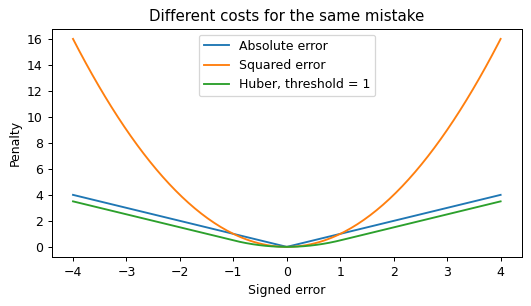

In [3]:
outlier_targets = torch.tensor([20., 20., 32.])
for constant in [20., 24.]:
    guesses = torch.full_like(outlier_targets, constant)
    print(f"Predict {constant:.0f}: MAE={nn.L1Loss()(guesses, outlier_targets):.3f}, "
          f"MSE={nn.MSELoss()(guesses, outlier_targets):.3f}")
errors = torch.linspace(-4, 4, 201)
zero = torch.zeros_like(errors)
huber = nn.HuberLoss(delta=1., reduction="none")(errors, zero)
manual_huber = torch.where(errors.abs() <= 1., 0.5 * errors.square(), errors.abs() - 0.5)
torch.testing.assert_close(huber, manual_huber)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(errors, errors.abs(), label="Absolute error")
ax.plot(errors, errors.square(), label="Squared error")
ax.plot(errors, huber, label="Huber, threshold = 1")
ax.set(xlabel="Signed error", ylabel="Penalty", title="Different costs for the same mistake")
ax.legend()
plt.tight_layout()
plt.show()

## Binary cross-entropy rewards probability on the true outcome

Here every target is positive. The binary probability estimates are `0.9`, `0.6`, and `0.1`; the penalty is minus the natural logarithm of that probability. We convert these moderate probabilities into logits using `log(p / (1 - p))` only to construct the example. In an actual classifier, the model would supply raw logits directly.

In [4]:
p = torch.tensor([[0.9], [0.6], [0.1]], dtype=torch.float64)
y = torch.ones_like(p)
logits = torch.log(p / (1 - p))
manual_bce = -(y * torch.log(p) + (1 - y) * torch.log1p(-p))
library_bce = nn.BCEWithLogitsLoss(reduction="none")(logits, y)
torch.testing.assert_close(library_bce, manual_bce)
for probability, penalty in zip(p.flatten(), library_bce.flatten()):
    print(f"P(positive)={probability:.1f}, target=positive, loss={penalty:.3f}")
assert library_bce[0] < library_bce[1] < library_bce[2]

P(positive)=0.9, target=positive, loss=0.105
P(positive)=0.6, target=positive, loss=0.511
P(positive)=0.1, target=positive, loss=2.303


## Keep the calculation stable for extreme confidence

Large positive and negative logits make sigmoid approach its endpoints. Rather than explicitly taking logarithms of those rounded probabilities, use the combined loss. The stable manual expression uses `log1p`, which accurately evaluates the logarithm of one plus a value. Confidently wrong examples below incur a large but finite penalty.

In [5]:
extreme_logits = torch.tensor([[1000.], [-1000.], [1000.], [-1000.]])
extreme_targets = torch.tensor([[1.], [0.], [0.], [1.]])
stable_manual = (torch.clamp(extreme_logits, min=0) - extreme_logits * extreme_targets
                 + torch.log1p(torch.exp(-extreme_logits.abs())))
stable_library = nn.BCEWithLogitsLoss(reduction="none")(extreme_logits, extreme_targets)
torch.testing.assert_close(stable_library, stable_manual)
assert torch.isfinite(stable_library).all()
print("Correctly confident, then incorrectly confident losses:")
print(stable_library.flatten().tolist())
print("All finite:", torch.isfinite(stable_library).all().item())

Correctly confident, then incorrectly confident losses:
[0.0, 0.0, 1000.0, 1000.0]
All finite: True


## Pick one of several classes

Columns represent normal, too dry, and too hot. Each row has exactly one correct class, stored as an integer index in a one-dimensional `torch.long` tensor. `CrossEntropyLoss` takes raw logits. For the manual comparison, `log_softmax` computes stable log probabilities, and indexing selects the correct class in each row.

In [6]:
class_names = ["normal", "too dry", "too hot"]
class_logits = torch.tensor([[2., 1., 0.], [2., 1., 0.]], dtype=torch.float64)
class_targets = torch.tensor([0, 2], dtype=torch.long)
log_probabilities = torch.log_softmax(class_logits, dim=1)
manual_ce = -log_probabilities[torch.arange(len(class_targets)), class_targets]
library_ce = nn.CrossEntropyLoss(reduction="none")(class_logits, class_targets)
torch.testing.assert_close(library_ce, manual_ce)
print("Displayed probabilities:\n", torch.softmax(class_logits, dim=1))
for true_class, penalty in zip(class_targets, library_ce):
    print(f"Target={class_names[true_class.item()]:7s}, loss={penalty:.3f}")
# Adding the same constant to all class scores must not change their probabilities or loss.
torch.testing.assert_close(nn.CrossEntropyLoss(reduction="none")(class_logits + 1000, class_targets), library_ce)

Displayed probabilities:
 tensor([[0.6652, 0.2447, 0.0900],
        [0.6652, 0.2447, 0.0900]], dtype=torch.float64)
Target=normal , loss=0.408
Target=too hot, loss=2.408


## Inspect reduction and guard against accidental broadcasting

A mean summarizes per-element penalties, while a sum grows with their count. If batch sizes differ, weight batch means by their element counts to recover the full average. We also deliberately subtract a target vector from a prediction column: this creates a matrix of pairwise errors, which is not the intended one-error-per-example calculation.

In [7]:
flat_penalties = squared.flatten()
batches = [flat_penalties[:2], flat_penalties[2:]]
unweighted_batch_average = torch.stack([batch.mean() for batch in batches]).mean()
weighted_batch_average = sum(batch.mean() * batch.numel() for batch in batches) / flat_penalties.numel()
torch.testing.assert_close(weighted_batch_average, squared.mean())
print(f"Mean of batch means: {unweighted_batch_average:.3f}")
print(f"Correct element-weighted mean: {weighted_batch_average:.3f}")
repeated = squared.repeat(2, 1)
torch.testing.assert_close(repeated.mean(), squared.mean())
torch.testing.assert_close(repeated.sum(), 2 * squared.sum())
wrong_errors = prediction - target.squeeze(1)
print("Correct error shape:", tuple(error.shape), "| incorrect:", tuple(wrong_errors.shape))
print(f"Intended MSE: {squared.mean():.3f}; accidental pairwise MSE: {wrong_errors.square().mean():.3f}")
assert wrong_errors.shape == (3, 3)
assert not torch.isclose(wrong_errors.square().mean(), squared.mean())

Mean of batch means: 5.750
Correct element-weighted mean: 4.667
Correct error shape: (3, 1) | incorrect: (3, 3)
Intended MSE: 4.667; accidental pairwise MSE: 7.333


## Equal accuracy can hide different confidence

The two sets of predictions make the same correct binary decisions. Cross-entropy distinguishes the probability assigned to the correct outcomes. This is an arithmetic illustration, not an experiment on a trained model or evidence that confidence is always justified.

In [8]:
binary_targets = torch.tensor([[1.], [0.]])
for name, probabilities in [
    ("Tentative", torch.tensor([[0.6], [0.4]])),
    ("Confident", torch.tensor([[0.9], [0.1]])),
]:
    scores = torch.logit(probabilities)
    accuracy = ((probabilities > 0.5).float() == binary_targets).float().mean()
    loss = nn.BCEWithLogitsLoss()(scores, binary_targets)
    print(f"{name:10s}: accuracy={accuracy:.1%}, binary cross-entropy={loss:.3f}")

Tentative : accuracy=100.0%, binary cross-entropy=0.511
Confident : accuracy=100.0%, binary cross-entropy=0.105


## Interpret the comparisons

Manual penalties matched PyTorch's implementations. Squared error emphasized larger misses, binary and multiclass cross-entropy depended on probability assigned to the target, and the combined logit-based calculation stayed finite for extreme scores. Reduction and shape checks exposed ways a valid computation can answer the wrong question.

Loss is an objective-specific number, not a universal measure of model quality. These examples used no fitting, so there is no need for a training/test split and no claim about generalization.

In [ ]:
import torch.nn.functional as F
loss_logits = torch.tensor([[2., 1., 0.], [0., 2., 1.]])
indices = torch.tensor([1, 2]); one_hot = F.one_hot(indices, 3).float()
index_loss = F.cross_entropy(loss_logits, indices, reduction='none')
one_hot_loss = F.cross_entropy(loss_logits, one_hot, reduction='none')
torch.testing.assert_close(index_loss, one_hot_loss)
h_scores = torch.tensor([2., .4, -.5]); h_labels = torch.ones(3)
h_values = (1 - h_labels * h_scores).clamp_min(0)
torch.testing.assert_close(h_values, torch.tensor([0., .6, 1.5]))
P = torch.tensor([[.75, .25]]); Q = torch.tensor([[.5, .5]])
kl = F.kl_div(Q.log(), P, reduction='batchmean')
torch.testing.assert_close(kl, (P * (P.log() - Q.log())).sum())
print('cross-entropy:', index_loss.tolist(), '| hinge:', h_values.tolist(), '| KL:', kl.item())